# Long/Short Factor-Based GTAA Portfolio — Final Submission

**Columbia University · MAFN · MATH 5380 · Spring 2026**

Single consolidated submission notebook. Covers data loading, signal construction,
rank-standardised raw FMP weights, 36-month rolling covariance, sleeve-level and
family-level 1% vol scaling, the final 1% vol portfolio, growth of $1 for the
portfolio and each sleeve/family, portfolio statistics, turnover, and the final
covariance / volatility / correlation matrices (both Nov-2025 and Dec-2025).

This notebook is the **main submitted notebook** for Project 2. The expanded
strategy shown here is the submitted model.

## Introduction

This notebook constructs a long/short GTAA portfolio using **two economic factor
families**: **Cross-Asset Momentum** and **Cross-Asset Carry**. Six implementation
sleeves underlie the two families:

- **Cross-Asset Momentum** — Equity Momentum, Commodity Momentum, Fixed-Income Momentum, FX Momentum
- **Cross-Asset Carry** — Fixed-Income Carry, FX Carry

Each sleeve is a **long/short factor-mimicking portfolio (FMP)** within its own
asset class. Sleeve weights are then grouped into the Momentum and Carry families,
each scaled to 1% annualised volatility, combined with equal family weights, and
rescaled again to a **1% annualised portfolio volatility target**.

> The audit notebook
> [`09_no_lookahead_verification.ipynb`](09_no_lookahead_verification.ipynb)
> contains the dedicated no-look-ahead audit for the **expanded submission**
> (signal timing, covariance windowing, weight-to-return alignment,
> carry pass-through verification, and future-shock contamination tests).


## How This Notebook Maps to the Project Requirements

| Project brief item | Where it is addressed |
|---|---|
| 1. Select investment universe | Sections 1 to 3 |
| 2. Construct factor-mimicking portfolios | Sections 4 and 5 |
| 3. Estimate covariance matrices | Section 6 |
| 4. Scale FMP weights to 1% volatility | Sections 7 to 10 |
| 5. Backtest the portfolio and report gross returns / statistics | Sections 11 to 13 |
| 6. Provide raw weights and 1% volatility weight panels through time | Sections 5 and 7 to 10 |
| 7. Provide final covariance, volatility, and correlation outputs | Section 14 |

Questions 6 and 7 from the project brief are addressed explicitly in the raw
weight, scaled-weight, turnover, covariance, volatility, and correlation
sections below.


## 1. Setup and Data Sources

We load monthly multi-asset data from the project workbook
`data/raw/multi_asset_universe.xlsx`. The workbook is the only raw input
needed; the notebook and imported project loaders perform all transformations
used in the submission.

| Asset class | Source                | Signal source                                      |
|-------------|----------------------|----------------------------------------------------|
| Equity      | Yahoo Finance ETFs   | MSCI monthly returns (`equity_msci_returns`)       |
| Commodity   | Yahoo Finance ETFs   | Price-based momentum (`commodity_prices`)          |
| Fixed Income| Yahoo Finance ETFs   | FRED yield proxies (`fi_carry_signals`)            |
| FX          | Yahoo Finance ETFs   | FRED 3M interbank rates (`fx_carry_signals`)       |


In [1]:
# Light imports + path setup
import sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make src importable (notebook runs from notebooks/)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from gtaa.io.excel_loader import load_gtaa_expanded_data
from gtaa.factors.signals import (
    momentum_12_1_from_returns,
    momentum_12_1_from_prices,
    fixed_income_carry_signal,
)
from gtaa.factors.ranking import rank_standardized_weights
from gtaa.risk.covariance import rolling_covariance_partial
from gtaa.risk.scaling import scale_weight_panel
from gtaa.portfolio.fmp import combine_weight_panels
from gtaa.portfolio.returns import portfolio_returns_from_weights
from gtaa.portfolio.turnover import compute_turnover

# Plot style
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.3,
})
CU_NAVY, CU_GOLD, CU_BLUE = "#003087", "#F2A900", "#75AADB"


## 2. Loading, Cleaning, and Alignment

Load the workbook through the project loader. The loader does the basic cleaning
(date index, numeric coercion, sheet-by-sheet alignment) and exposes each asset
class as its own DataFrame.


In [2]:
WORKBOOK = ROOT / "data/raw/multi_asset_universe.xlsx"
data = load_gtaa_expanded_data(WORKBOOK)

print(f"Equity returns:    {data.equity_returns.index[0].date()} → {data.equity_returns.index[-1].date()}  ({data.equity_returns.shape})")
print(f"Commodity prices:  {data.commodity_prices.index[0].date()} → {data.commodity_prices.index[-1].date()}  ({data.commodity_prices.shape})")
print(f"FI returns:        {data.fi_returns.index[0].date()} → {data.fi_returns.index[-1].date()}  ({data.fi_returns.shape})")
print(f"FX returns:        {data.fx_returns.index[0].date()} → {data.fx_returns.index[-1].date()}  ({data.fx_returns.shape})")
print(f"FI carry signals:  {data.fi_carry.index[0].date()} → {data.fi_carry.index[-1].date()}  ({data.fi_carry.shape})")
print(f"FX carry signals:  {data.fx_carry.index[0].date()} → {data.fx_carry.index[-1].date()}  ({data.fx_carry.shape})")


Equity returns:    1970-01-31 → 2025-12-31  ((672, 10))
Commodity prices:  2004-11-30 → 2026-05-31  ((259, 12))
FI returns:        2002-08-31 → 2026-05-31  ((286, 10))
FX returns:        2006-01-31 → 2026-05-31  ((245, 6))
FI carry signals:  1953-04-30 → 2026-04-30  ((877, 10))
FX carry signals:  2005-12-31 → 2026-03-31  ((244, 6))


### 2.1 Data-Handling Detail

The loader does the following per sheet:

1. **Date parsing.** First column → `DatetimeIndex` (month-end frequency).
2. **Numeric coercion.** All non-date columns coerced via `pd.to_numeric(errors="coerce")`.
3. **Sort + dedupe.** Index sorted ascending, duplicates removed.
4. **Per-asset NaN policy.** No forward-fill of returns or yields — missing months
   are left as `NaN` so the partial-universe logic in covariance / scaling sees
   them and excludes those assets from the active cross-section at that date.
5. **Cross-sleeve alignment.** Each sleeve keeps its own DataFrame; alignment to
   the combined cross-asset panel happens later via `combined_returns`.

Below we explicitly show the NaN profile, dtype check, and alignment so the
data-handling step is reproducible without opening the loader source.


In [3]:
# Per-sleeve NaN counts and dtype check (data quality)
qc_rows = []
for label, df in [
    ("Equity returns",    data.equity_returns),
    ("Commodity prices",  data.commodity_prices),
    ("Commodity returns", data.commodity_returns),
    ("FI returns",        data.fi_returns),
    ("FI carry signal",   data.fi_carry),
    ("FX prices",         data.fx_prices),
    ("FX returns",        data.fx_returns),
    ("FX carry signal",   data.fx_carry),
]:
    qc_rows.append({
        "Sheet":              label,
        "Rows":               df.shape[0],
        "Cols":               df.shape[1],
        "First valid date":   df.index[0].date(),
        "Last valid date":    df.index[-1].date(),
        "Total NaN cells":    int(df.isna().sum().sum()),
        "% NaN":              f"{df.isna().mean().mean()*100:.2f}%",
        "All numeric dtype":  bool((df.dtypes == float).all() or (df.dtypes.apply(lambda d: pd.api.types.is_numeric_dtype(d))).all()),
    })
pd.DataFrame(qc_rows)


,Sheet,Rows,Cols,First valid date,Last valid date,Total NaN cells,% NaN,All numeric dtype
0,Equity returns,672,10,1970-01-31,2025-12-31,0,0.00%,True
1,Commodity prices,259,12,2004-11-30,2026-05-31,595,19.14%,True
2,Commodity returns,258,12,2004-12-31,2026-05-31,595,19.22%,True
3,FI returns,286,10,2002-08-31,2026-05-31,359,12.55%,True
4,FI carry signal,877,10,1953-04-30,2026-04-30,2978,33.96%,True
5,FX prices,246,6,2005-12-31,2026-05-31,38,2.57%,True
6,FX returns,245,6,2006-01-31,2026-05-31,38,2.59%,True
7,FX carry signal,244,6,2005-12-31,2026-03-31,10,0.68%,True


> **Effective sleeve start dates.** Commodity ETFs only listed from Nov-2004;
> FX ETFs from 2005–2006. Each sleeve uses a partial-universe approach so that
> the cross-section grows as new tickers come online. The expanded portfolio
> binds at the latest sleeve start (Dec-2005) once all four FX ETFs are active.


## 3. Investment Universe (Project Requirement 1)

The full universe spans 38 instruments across four asset classes.

- **Equity (10):** EWA, EWC, EWQ, EWG, EWI, EWJ, EWN, EWP, EWU, SPY
- **Commodity (12):** GLD, SLV, CPER, PPLT, PALL, USO, BNO, UNG, DBA, CORN, WEAT, SOYB
- **Fixed Income (10):** SHV, SHY, IEI, IEF, TLH, TLT, VTIP, TIP, LQD, HYG
- **FX (6):** FXE, FXY, FXB, FXA, FXC, FXF

Signals are ranked **only within their own asset-class sleeve**, never pooled
across asset classes. This avoids comparing fundamentally different signal
units (FX rate differentials, bond yield proxies, commodity price momentum).


In [4]:
SLEEVE_TICKERS = {
    "equity_momentum":        ["EWA","EWC","EWQ","EWG","EWI","EWJ","EWN","EWP","EWU","SPY"],
    "commodity_momentum":     ["GLD","SLV","CPER","PPLT","PALL","USO","BNO","UNG","DBA","CORN","WEAT","SOYB"],
    "fixed_income_momentum":  ["SHV","SHY","IEI","IEF","TLH","TLT","VTIP","TIP","LQD","HYG"],
    "fx_momentum":            ["FXE","FXY","FXB","FXA","FXC","FXF"],
    "fixed_income_carry":     ["SHV","SHY","IEI","IEF","TLH","TLT","VTIP","TIP","LQD","HYG"],
    "fx_carry":               ["FXE","FXY","FXB","FXA","FXC","FXF"],
}
{k: len(v) for k, v in SLEEVE_TICKERS.items()}


{'equity_momentum': 10,
 'commodity_momentum': 12,
 'fixed_income_momentum': 10,
 'fx_momentum': 6,
 'fixed_income_carry': 10,
 'fx_carry': 6}

## 4. Factor-Family Design and Signal Construction (Project Requirement 2)

### 4.1 Cross-Asset Momentum

**Return-based 12-1 momentum** (Equity, Fixed Income):

$$
s^{\text{mom}}_{i,t} \;=\; \prod_{k=2}^{12}\!\bigl(1 + r_{i,t-k}\bigr) \;-\; 1
$$

We use cumulative returns from $t{-}12$ through $t{-}2$, skipping the most
recent month to reduce short-term reversal contamination.

**Price-based 12-1 momentum** (Commodity, FX) — the equivalent lagged price ratio:

$$
s^{\text{mom}}_{i,t} \;=\; \frac{P_{i,t-2}}{P_{i,t-13}} \;-\; 1
$$

### 4.2 Cross-Asset Carry

**Fixed-Income Carry** is a pass-through of pre-computed yield/carry-proxy
series — higher yield ⇒ higher carry rank.

**FX Carry** in the expanded version is the foreign 3-month rate minus the
USD 3-month rate (FRED IR3TIB01 series).


In [5]:
# Compute the six sleeve signals
signals = {}
signals["equity_momentum"]       = momentum_12_1_from_returns(data.equity_returns[SLEEVE_TICKERS["equity_momentum"]])
signals["commodity_momentum"]    = momentum_12_1_from_prices(data.commodity_prices[SLEEVE_TICKERS["commodity_momentum"]])
signals["fixed_income_momentum"] = momentum_12_1_from_returns(data.fi_returns[SLEEVE_TICKERS["fixed_income_momentum"]])
signals["fx_momentum"]           = momentum_12_1_from_prices(data.fx_prices[SLEEVE_TICKERS["fx_momentum"]])
signals["fixed_income_carry"]    = data.fi_carry[SLEEVE_TICKERS["fixed_income_carry"]].copy()
signals["fx_carry"]              = data.fx_carry[SLEEVE_TICKERS["fx_carry"]].copy()

# Sample of equity momentum signals (most recent 5 months)
signals["equity_momentum"].dropna(how="all").tail(5).round(4)


,EWA,EWC,EWQ,EWG,EWI,EWJ,EWN,EWP,EWU,SPY
date,,,,,,,,,,
2025-08-31,0.0853,0.1958,0.0483,0.2689,0.2196,-0.0107,-0.0183,0.3209,0.0791,0.1392
2025-09-30,0.1016,0.1973,0.0473,0.2479,0.2351,0.0111,-0.0521,0.3392,0.1160,0.1380
2025-10-31,0.0923,0.2190,0.0330,0.2008,0.2839,0.0611,-0.0219,0.3399,0.1536,0.1360
2025-11-30,0.0913,0.2713,0.1006,0.2123,0.2907,0.1377,0.2103,0.4104,0.1890,0.1864
2025-12-31,0.0512,0.1994,0.1487,0.1783,0.3368,0.2190,0.2426,0.4748,0.2078,0.1432


## 5. Raw Factor Weights (Project Requirement 6)

Each sleeve signal is converted to **cross-sectional rank-standardised weights**:

$$
w^{\text{raw}}_{i,t} \;=\; \frac{\,\text{rank}(s_{i,t}) - \overline{\text{rank}}_{t}\,}{\sigma_{\text{rank},t}}
$$

with population std (`ddof=0`). This is **zero-sum by construction**, so each
sleeve is a pure long/short FMP. Ranges are bounded by
$\pm\sqrt{N{-}1}/\sqrt{N}$ for a cross-section of size $N$.


In [6]:
raw_weights = {sk: rank_standardized_weights(sig) for sk, sig in signals.items()}
for sk, w in raw_weights.items():
    print(f"  {sk:24s}  shape={w.shape}  zero-sum check (max |row sum|): {w.sum(axis=1).abs().max():.2e}")


  equity_momentum           shape=(672, 10)  zero-sum check (max |row sum|): 1.11e-15
  commodity_momentum        shape=(259, 12)  zero-sum check (max |row sum|): 8.88e-16
  fixed_income_momentum     shape=(286, 10)  zero-sum check (max |row sum|): 5.55e-16
  fx_momentum               shape=(246, 6)  zero-sum check (max |row sum|): 2.78e-16
  fixed_income_carry        shape=(877, 10)  zero-sum check (max |row sum|): 6.66e-16
  fx_carry                  shape=(244, 6)  zero-sum check (max |row sum|): 2.22e-16


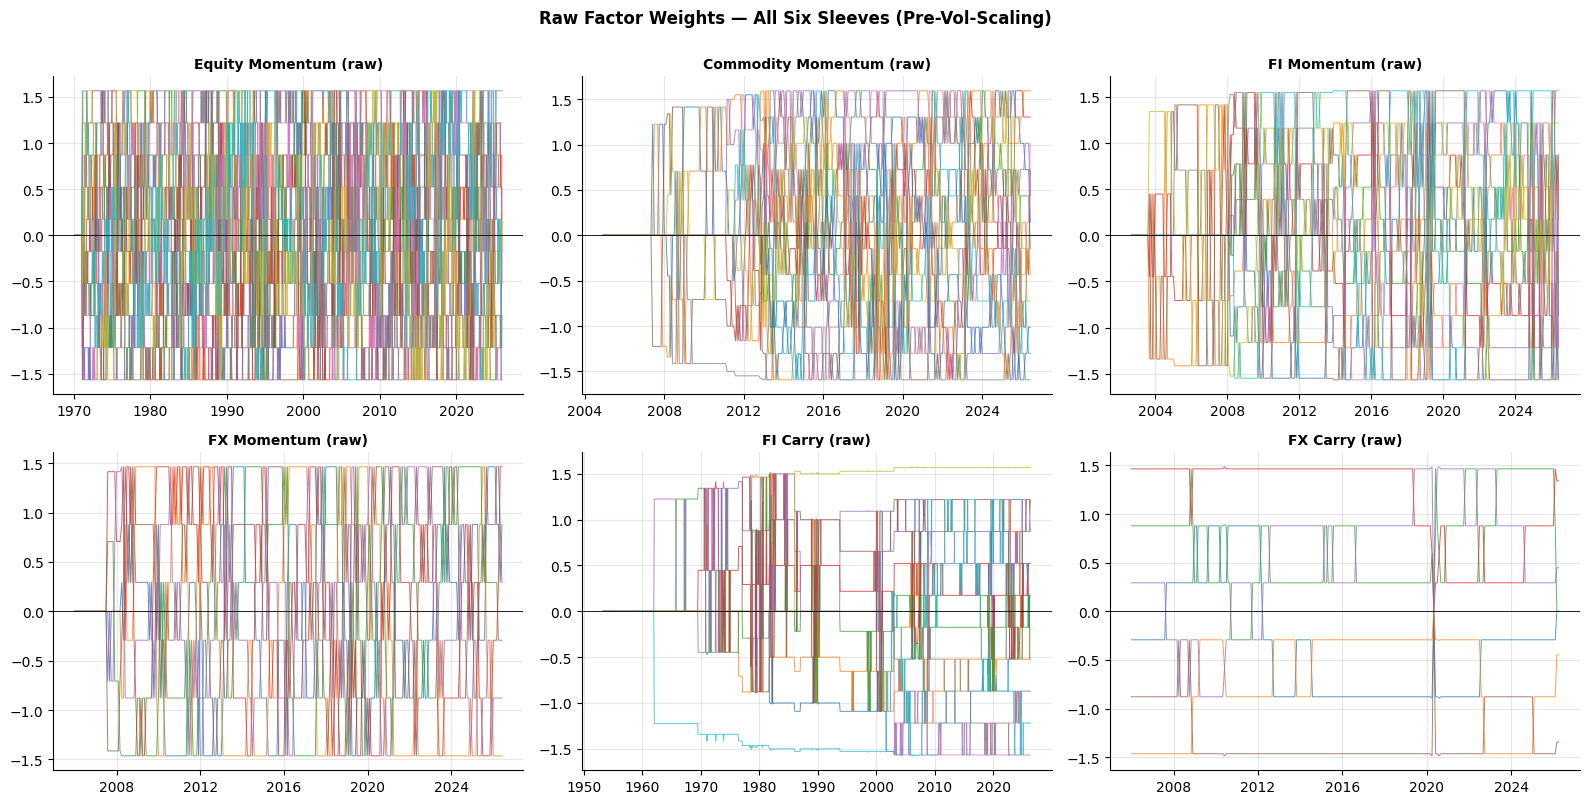

In [7]:
# Plot raw weights for the four momentum sleeves (top) and two carry sleeves (bottom)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)
order = [
    ("equity_momentum","Equity Momentum (raw)"),
    ("commodity_momentum","Commodity Momentum (raw)"),
    ("fixed_income_momentum","FI Momentum (raw)"),
    ("fx_momentum","FX Momentum (raw)"),
    ("fixed_income_carry","FI Carry (raw)"),
    ("fx_carry","FX Carry (raw)"),
]
for ax, (sk, title) in zip(axes.flat, order):
    w = raw_weights[sk].dropna(how="all")
    ax.plot(w.index, w.values, lw=0.7, alpha=0.75)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(title, fontsize=10, fontweight="bold")
plt.suptitle("Raw Factor Weights — All Six Sleeves (Pre-Vol-Scaling)", fontsize=12, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()


## 6. 36-Month Rolling Covariance Estimation (Project Requirement 3)

For each month $t$, we estimate a **population covariance matrix** (`ddof=0`)
from the 36 most recent monthly returns, annualised by $\times 12$:

$$
\Sigma_t \;=\; \frac{12}{36}\sum_{k=0}^{35} \bigl(r_{t-k} - \bar r\bigr)\bigl(r_{t-k} - \bar r\bigr)^{\!\top}
$$

Only data **available at $t$** is used (`returns.loc[:t].tail(36)`), so there
is no look-ahead. Partial-universe handling allows new tickers to enter the
covariance once they have 36 months of history.


In [8]:
# Concatenate per-asset-class returns into a single panel for cross-sleeve covariance
def returns_for_sleeve(sk):
    if sk in ("equity_momentum",):                     return data.equity_returns[SLEEVE_TICKERS[sk]]
    if sk in ("commodity_momentum",):                  return data.commodity_returns[SLEEVE_TICKERS[sk]]
    if sk in ("fixed_income_momentum","fixed_income_carry"): return data.fi_returns[SLEEVE_TICKERS[sk]]
    if sk in ("fx_momentum","fx_carry"):               return data.fx_returns[SLEEVE_TICKERS[sk]]
    raise KeyError(sk)

sleeve_returns_for_cov = {sk: returns_for_sleeve(sk) for sk in SLEEVE_TICKERS}

# Combined cross-asset returns — used at family + final portfolio level
all_assets = sorted({a for tickers in SLEEVE_TICKERS.values() for a in tickers})
combined_returns = pd.concat([
    data.equity_returns,
    data.commodity_returns,
    data.fi_returns,
    data.fx_returns,
], axis=1).loc[:, lambda df: ~df.columns.duplicated()].reindex(columns=all_assets)
print(f"Combined panel shape: {combined_returns.shape}, range {combined_returns.index[0].date()} → {combined_returns.index[-1].date()}")


Combined panel shape: (677, 38), range 1970-01-31 → 2026-05-31


## 7. Sleeve-Level 1% Volatility Scaling (Project Requirement 4)

Each raw FMP is scaled to **1% annualised ex-ante volatility**:

$$
w^{\text{scaled}}_{t} \;=\; w^{\text{raw}}_{t} \cdot \frac{\sigma_{\text{target}}}{\sqrt{\,w_{t}^{\text{raw}\!\top}\,\Sigma_{t}\,w^{\text{raw}}_{t}\,}}
$$

with $\sigma_{\text{target}} = 0.01$. Scaling is applied independently to each
of the six sleeves before any family-level aggregation.


In [9]:
LOOKBACK = 36
TARGET_VOL = 0.01

sleeve_scaled = {}
for sk, raw_w in raw_weights.items():
    sleeve_rets = sleeve_returns_for_cov[sk]
    # Rolling cov per sleeve cross-section (partial-universe safe)
    sleeve_scaled[sk] = scale_weight_panel(raw_w, sleeve_rets, lookback=LOOKBACK, target_vol=TARGET_VOL)

for sk, w in sleeve_scaled.items():
    print(f"  {sk:24s}  scaled shape={w.shape}  first valid date: {w.dropna(how='all').index[0].date()}")


  equity_momentum           scaled shape=(672, 10)  first valid date: 1970-01-31
  commodity_momentum        scaled shape=(259, 12)  first valid date: 2004-11-30
  fixed_income_momentum     scaled shape=(286, 10)  first valid date: 2002-08-31
  fx_momentum               scaled shape=(246, 6)  first valid date: 2005-12-31


  fixed_income_carry        scaled shape=(877, 10)  first valid date: 1953-04-30
  fx_carry                  scaled shape=(244, 6)  first valid date: 2005-12-31


## 8. Factor 1 — Cross-Asset Momentum: 1% Volatility Family Weights (Project Requirement 6)

The four momentum sleeves are equal-weighted (¼ each), then the resulting
combined panel is **rescaled again** to 1% annualised volatility using the full
cross-asset covariance.


Momentum family weights: (241, 38)
First valid date: 2005-12-31


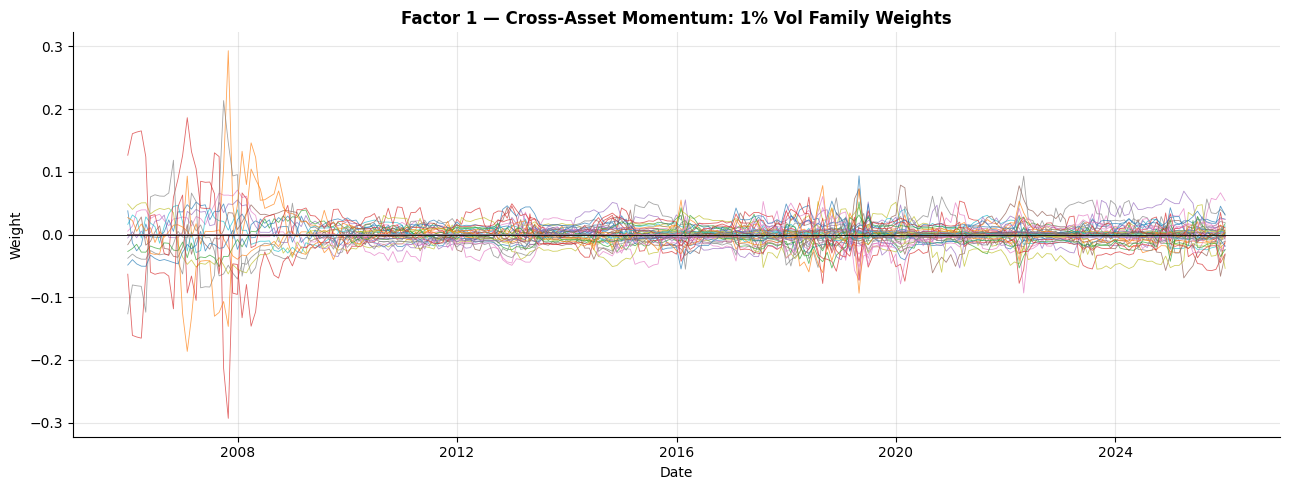

In [10]:
mom_components = {
    "equity_momentum":        0.25,
    "commodity_momentum":     0.25,
    "fixed_income_momentum":  0.25,
    "fx_momentum":            0.25,
}
mom_combined_raw = combine_weight_panels(
    {k: sleeve_scaled[k] for k in mom_components}, mom_components,
)
mom_family_weights = scale_weight_panel(
    mom_combined_raw, combined_returns, lookback=LOOKBACK, target_vol=TARGET_VOL,
)
print(f"Momentum family weights: {mom_family_weights.shape}")
print(f"First valid date: {mom_family_weights.dropna(how='all').index[0].date()}")

# Plot the family weight panel
fig, ax = plt.subplots(figsize=(13, 5))
mw = mom_family_weights.dropna(how="all")
ax.plot(mw.index, mw.values, lw=0.6, alpha=0.7)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Factor 1 — Cross-Asset Momentum: 1% Vol Family Weights", fontsize=12, fontweight="bold")
ax.set_ylabel("Weight"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()


## 9. Factor 2 — Cross-Asset Carry: 1% Volatility Family Weights (Project Requirement 6)

The two carry sleeves are equal-weighted (½ each) and the combined panel is
rescaled to 1% volatility using the full cross-asset covariance.


Carry family weights: (244, 38)
First valid date: 2005-12-31


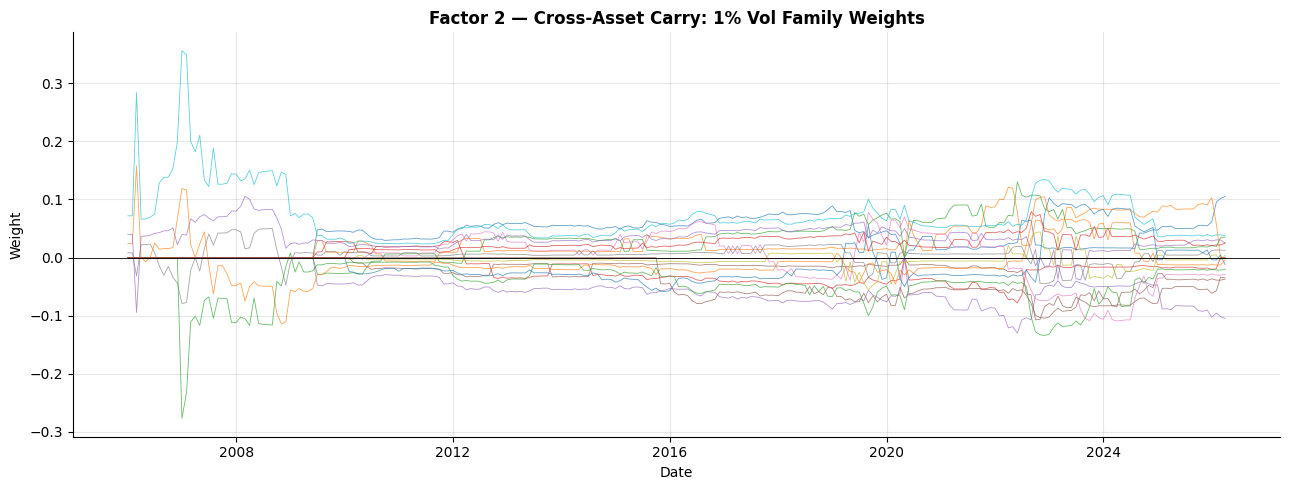

In [11]:
carry_components = {
    "fixed_income_carry": 0.50,
    "fx_carry":           0.50,
}
carry_combined_raw = combine_weight_panels(
    {k: sleeve_scaled[k] for k in carry_components}, carry_components,
)
carry_family_weights = scale_weight_panel(
    carry_combined_raw, combined_returns, lookback=LOOKBACK, target_vol=TARGET_VOL,
)
print(f"Carry family weights: {carry_family_weights.shape}")
print(f"First valid date: {carry_family_weights.dropna(how='all').index[0].date()}")

fig, ax = plt.subplots(figsize=(13, 5))
cw = carry_family_weights.dropna(how="all")
ax.plot(cw.index, cw.values, lw=0.6, alpha=0.7)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Factor 2 — Cross-Asset Carry: 1% Vol Family Weights", fontsize=12, fontweight="bold")
ax.set_ylabel("Weight"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()


## 10. Final 1% Volatility Portfolio Weights (Project Requirement 6)

The two family panels are combined with **equal family weights** (½ each)
and rescaled one more time to **1% annualised portfolio volatility**.


Final portfolio weights: (241, 38)
First valid date:        2005-12-31
Last  valid date:        2025-12-31


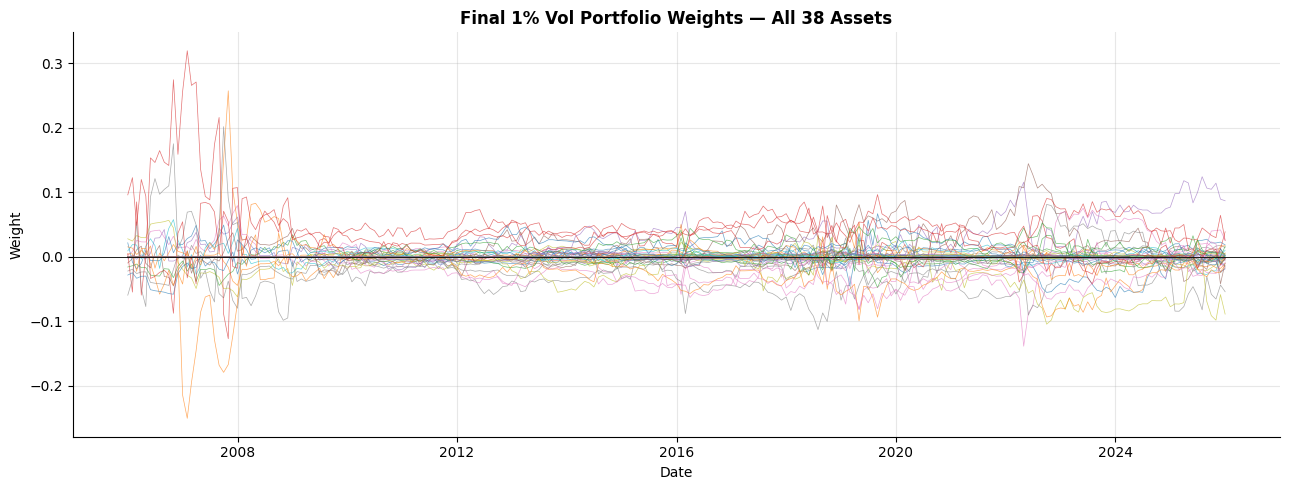

In [12]:
family_components = {
    "cross_asset_momentum": 0.50,
    "cross_asset_carry":    0.50,
}
families = {
    "cross_asset_momentum": mom_family_weights,
    "cross_asset_carry":    carry_family_weights,
}
final_combined_raw = combine_weight_panels(families, family_components)
final_weights = scale_weight_panel(
    final_combined_raw, combined_returns, lookback=LOOKBACK, target_vol=TARGET_VOL,
)
print(f"Final portfolio weights: {final_weights.shape}")
print(f"First valid date:        {final_weights.dropna(how='all').index[0].date()}")
print(f"Last  valid date:        {final_weights.dropna(how='all').index[-1].date()}")

fig, ax = plt.subplots(figsize=(13, 5))
fw = final_weights.dropna(how="all")
ax.plot(fw.index, fw.values, lw=0.5, alpha=0.65)
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Final 1% Vol Portfolio Weights — All 38 Assets", fontsize=12, fontweight="bold")
ax.set_ylabel("Weight"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()


## 11. Gross Returns and Growth of \\$1 (Project Requirement 5)

Weights formed at month-end $t$ earn returns in month $t{+}1$:

$$
r^{\text{port}}_{t+1} \;=\; \sum_{i} w_{i,t}\, r_{i,t+1}
$$

Cumulative wealth: $W_T = \prod_{t=1}^{T}\bigl(1 + r^{\text{port}}_{t}\bigr)$.


In [13]:
# Returns for: each sleeve, each family, final portfolio
sleeve_returns = {
    sk: portfolio_returns_from_weights(w, sleeve_returns_for_cov[sk])
    for sk, w in sleeve_scaled.items()
}
family_returns = {
    "cross_asset_momentum": portfolio_returns_from_weights(mom_family_weights, combined_returns),
    "cross_asset_carry":    portfolio_returns_from_weights(carry_family_weights, combined_returns),
}
final_returns = portfolio_returns_from_weights(final_weights, combined_returns)
print(f"Final portfolio returns: {final_returns.dropna().shape[0]} months "
      f"({final_returns.dropna().index[0].date()} → {final_returns.dropna().index[-1].date()})")


Final portfolio returns: 240 months (2005-12-31 → 2025-11-30)


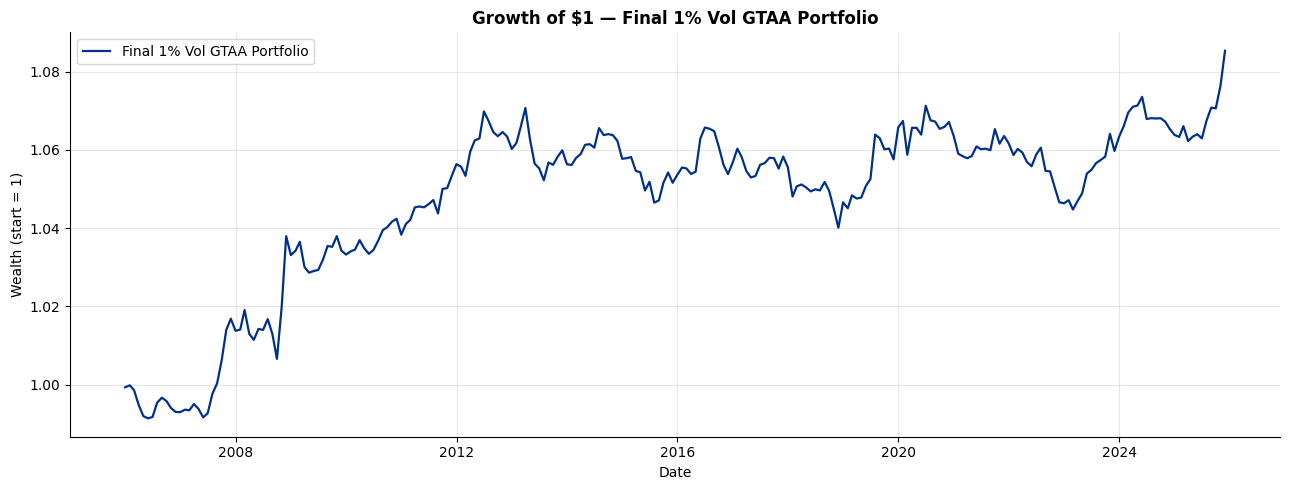

In [14]:
# Growth of $1 — final portfolio
fig, ax = plt.subplots(figsize=(13, 5))
g = (1 + final_returns.dropna()).cumprod()
ax.plot(g.index, g.values, color=CU_NAVY, lw=1.6, label="Final 1% Vol GTAA Portfolio")
ax.set_title("Growth of $1 — Final 1% Vol GTAA Portfolio", fontsize=12, fontweight="bold")
ax.set_ylabel("Wealth (start = 1)"); ax.set_xlabel("Date")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()


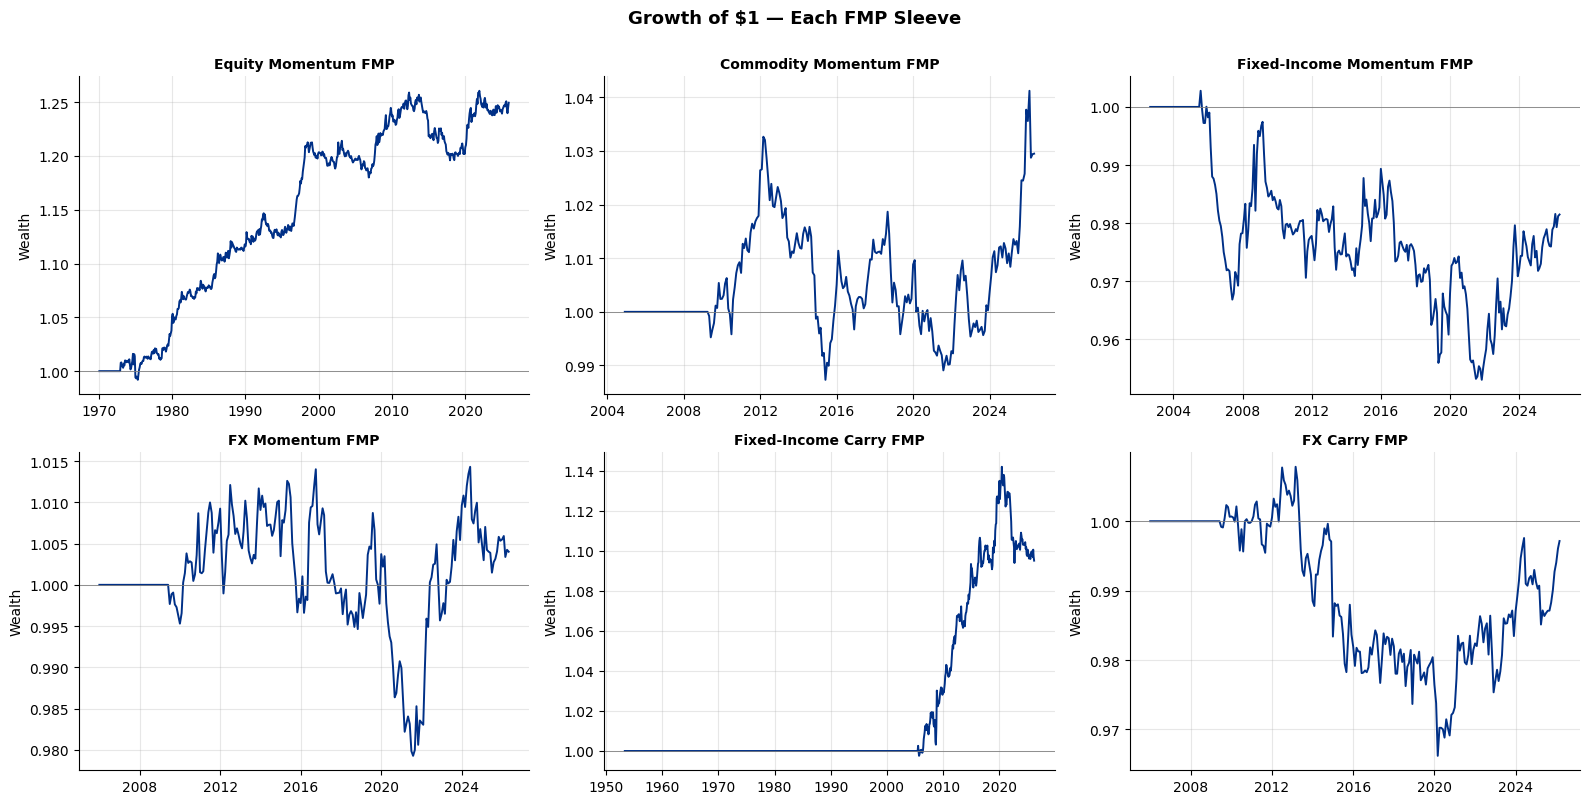

In [15]:
# Growth of $1 — each FMP sleeve (6 sleeves)
SLEEVE_LABELS = {
    "equity_momentum":        "Equity Momentum FMP",
    "commodity_momentum":     "Commodity Momentum FMP",
    "fixed_income_momentum":  "Fixed-Income Momentum FMP",
    "fx_momentum":            "FX Momentum FMP",
    "fixed_income_carry":     "Fixed-Income Carry FMP",
    "fx_carry":               "FX Carry FMP",
}
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (sk, label) in zip(axes.flat, SLEEVE_LABELS.items()):
    g = (1 + sleeve_returns[sk].dropna()).cumprod()
    ax.plot(g.index, g.values, color=CU_NAVY, lw=1.4)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel("Wealth"); ax.axhline(1, color="grey", lw=0.6)
plt.suptitle("Growth of $1 — Each FMP Sleeve", fontsize=13, fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()


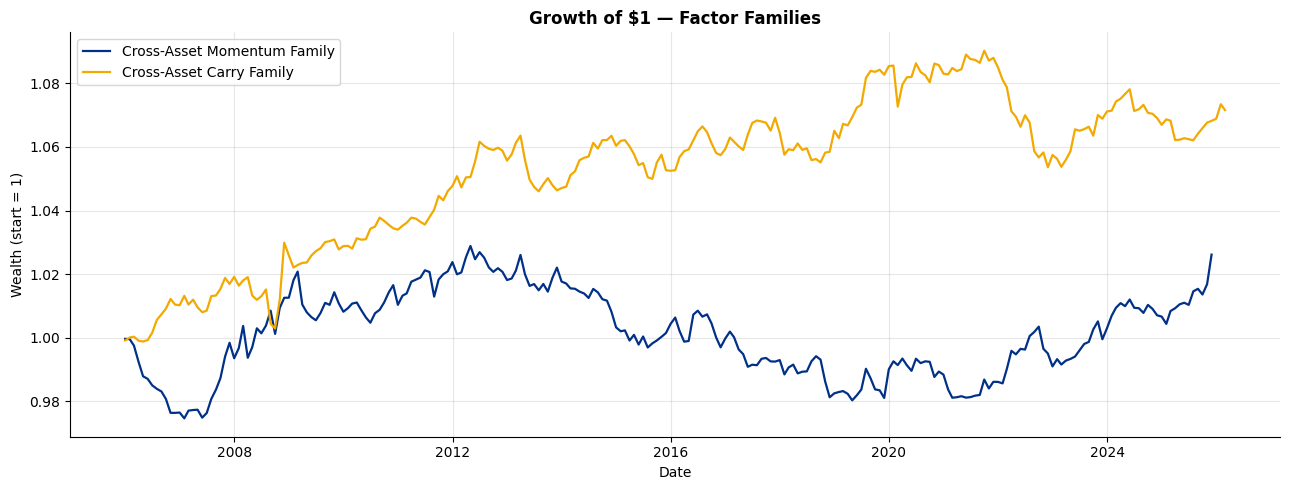

In [16]:
# Growth of $1 — two factor families
fig, ax = plt.subplots(figsize=(13, 5))
for key, label, c in [
    ("cross_asset_momentum", "Cross-Asset Momentum Family", CU_NAVY),
    ("cross_asset_carry",    "Cross-Asset Carry Family",    CU_GOLD),
]:
    g = (1 + family_returns[key].dropna()).cumprod()
    ax.plot(g.index, g.values, lw=1.6, label=label, color=c)
ax.legend(loc="upper left")
ax.set_title("Growth of $1 — Factor Families", fontsize=12, fontweight="bold")
ax.set_ylabel("Wealth (start = 1)"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()


## 12. Portfolio Statistics (Project Requirement 5)

Per the project guide, annualised return is the **arithmetic** simple-return
average scaled by 12:

$$
\text{Ann. return} \;=\; 12 \cdot \overline{r}_{\text{monthly}}
\quad,\quad
\text{Ann. vol} \;=\; \sqrt{12}\cdot\sigma_{\text{monthly}}\ (\text{ddof}=0)
$$

(We do **not** use a geometric/CAGR convention.) Information Ratio is the ratio
of annualised return to annualised volatility under the same convention.
Drawdowns use the geometric wealth path
$W_t = \prod_{s\le t}(1+r_s)$ for honest risk reporting.


In [17]:
def ann_return(r):  return r.dropna().mean() * 12        # arithmetic simple return × 12
def ann_vol(r):     return r.dropna().std(ddof=0) * np.sqrt(12)
def info_ratio(r):
    rd = r.dropna()
    return (rd.mean() * 12) / (rd.std(ddof=0) * np.sqrt(12))
def max_dd(r):
    cum = (1 + r.dropna()).cumprod(); peak = cum.cummax()
    return (cum/peak - 1).min()
def avg_dd(r):
    cum = (1 + r.dropna()).cumprod(); peak = cum.cummax()
    dd = cum/peak - 1
    return dd[dd < 0].mean()
def ann_turnover(w, rets):
    w = w.dropna(how="all")
    if len(w) < 2: return np.nan
    to = compute_turnover(w, rets).dropna()
    return to.mean() * 12 if len(to) else np.nan

rows = []
for sk, label in SLEEVE_LABELS.items():
    r = sleeve_returns[sk]; w = sleeve_scaled[sk]; rr = sleeve_returns_for_cov[sk]
    rows.append([label, ann_return(r), ann_vol(r), info_ratio(r), max_dd(r), avg_dd(r), ann_turnover(w, rr)])
for fk, label in [("cross_asset_momentum","Cross-Asset Momentum Family"),
                  ("cross_asset_carry","Cross-Asset Carry Family")]:
    r = family_returns[fk]; w = families[fk]
    rows.append([label, ann_return(r), ann_vol(r), info_ratio(r), max_dd(r), avg_dd(r), ann_turnover(w, combined_returns)])

rows.append(["Expanded Final GTAA",
             ann_return(final_returns), ann_vol(final_returns), info_ratio(final_returns),
             max_dd(final_returns), avg_dd(final_returns), ann_turnover(final_weights, combined_returns)])

stats = pd.DataFrame(rows, columns=[
    "Sleeve / Family", "Ann. return", "Ann. vol", "IR", "Max DD", "Avg DD", "Ann. Turnover"
])
stats_disp = stats.copy()
for c in ["Ann. return","Ann. vol","Max DD","Avg DD","Ann. Turnover"]:
    stats_disp[c] = stats_disp[c].apply(lambda x: f"{x*100:.2f}%")
stats_disp["IR"] = stats_disp["IR"].apply(lambda x: f"{x:.3f}")
stats_disp


,Sleeve / Family,Ann. return,Ann. vol,IR,Max DD,Avg DD,Ann. Turnover
0,Equity Momentum FMP,0.40%,1.08%,0.374,-5.00%,-1.25%,111.66%
1,Commodity Momentum FMP,0.14%,0.97%,0.144,-4.39%,-2.34%,36.01%
2,Fixed-Income Momentum FMP,-0.07%,0.99%,-0.075,-4.96%,-2.71%,187.82%
3,FX Momentum FMP,0.02%,0.87%,0.027,-3.43%,-1.08%,166.85%
4,Fixed-Income Carry FMP,0.13%,0.58%,0.217,-4.21%,-1.32%,64.70%
5,FX Carry FMP,-0.01%,0.87%,-0.012,-4.13%,-1.96%,24.82%
6,Cross-Asset Momentum Family,0.13%,1.09%,0.124,-4.72%,-2.29%,271.17%
7,Cross-Asset Carry Family,0.35%,1.06%,0.326,-3.36%,-0.92%,90.16%
8,Expanded Final GTAA,0.42%,1.15%,0.361,-2.86%,-1.01%,236.35%


## 13. Turnover (Project Requirements 5 and 6)

Monthly turnover is computed under the **funded-portfolio convention**:

$$
T_t \;=\; \tfrac{1}{2}\sum_{i}\bigl|\,w_{i,t} - w_{i,t-1}\,\bigr|
$$

(Annualised by $\times 12$.) The final portfolio target volatility constrains
gross exposure, so reported turnover is the post-scaling measure.


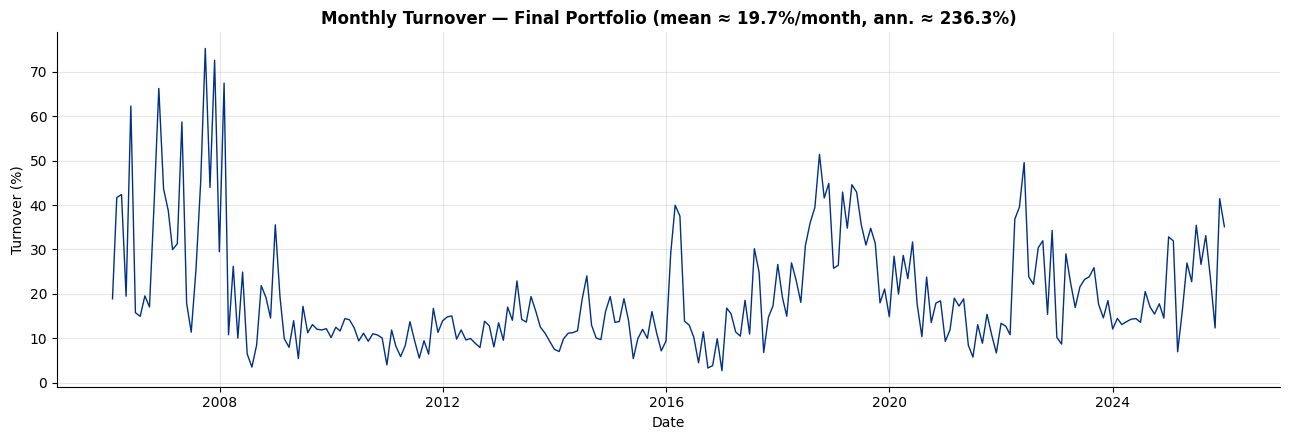

In [18]:
to = compute_turnover(final_weights, combined_returns).dropna()
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(to.index, to.values * 100, color=CU_NAVY, lw=1.0)
ax.set_title(f"Monthly Turnover — Final Portfolio (mean ≈ {to.mean()*100:.1f}%/month, ann. ≈ {to.mean()*12*100:.1f}%)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Turnover (%)"); ax.set_xlabel("Date")
plt.tight_layout(); plt.show()


## 14. Final Covariance, Volatility, and Correlation Matrices (Project Requirement 7)

We report the final-period 36-month rolling estimates twice:

- **Nov-2025** — last in-sample weight date (final weights formed here earn Dec-2025 returns).
- **Dec-2025** — last available data month, included for completeness even though no
  weight is formed against it (it is the *return* the Nov-2025 weights earn).

Volatilities are the diagonal of $\Sigma_t$; correlations come from
$\rho_t = D_t^{-1/2}\Sigma_t D_t^{-1/2}$ where $D_t=\text{diag}(\Sigma_t)$.


In [19]:
def panel_at(date_label, returns_panel, lookback=36):
    window = returns_panel.loc[:date_label].tail(lookback).dropna(axis=1, how="any")
    cov = window.cov(ddof=0) * 12
    vols = pd.Series(np.sqrt(np.diag(cov)), index=cov.index, name="ann_vol")
    corr = cov.div(vols, axis=0).div(vols, axis=1)
    return cov, vols, corr

cov_nov, vols_nov, corr_nov = panel_at("2025-11-30", combined_returns)
cov_dec, vols_dec, corr_dec = panel_at("2025-12-31", combined_returns)
print(f"Nov-2025 panel: {cov_nov.shape[0]} assets")
print(f"Dec-2025 panel: {cov_dec.shape[0]} assets")


Nov-2025 panel: 38 assets
Dec-2025 panel: 38 assets


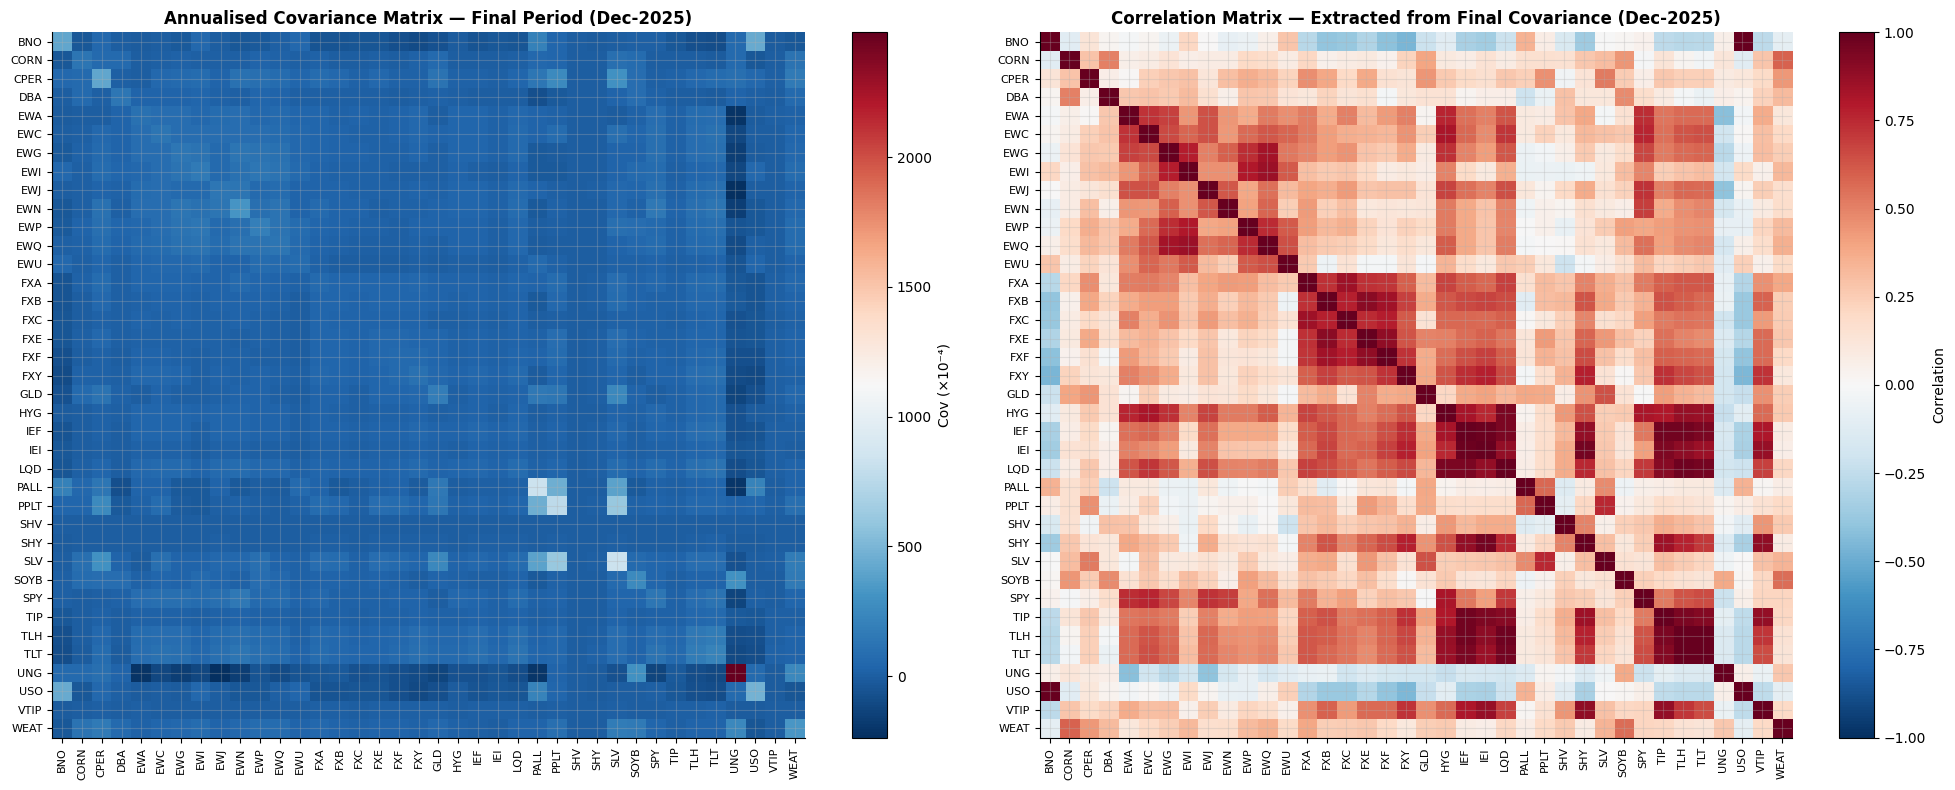

In [20]:
# Side-by-side covariance + correlation heatmaps for Dec-2025
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
im = axes[0].imshow(cov_dec.values * 1e4, cmap="RdBu_r", aspect="auto")
axes[0].set_xticks(range(len(cov_dec))); axes[0].set_yticks(range(len(cov_dec)))
axes[0].set_xticklabels(cov_dec.columns, rotation=90, fontsize=8)
axes[0].set_yticklabels(cov_dec.index, fontsize=8)
axes[0].set_title("Annualised Covariance Matrix — Final Period (Dec-2025)", fontweight="bold")
plt.colorbar(im, ax=axes[0], label="Cov (×10⁻⁴)")

im2 = axes[1].imshow(corr_dec.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(corr_dec))); axes[1].set_yticks(range(len(corr_dec)))
axes[1].set_xticklabels(corr_dec.columns, rotation=90, fontsize=8)
axes[1].set_yticklabels(corr_dec.index, fontsize=8)
axes[1].set_title("Correlation Matrix — Extracted from Final Covariance (Dec-2025)", fontweight="bold")
plt.colorbar(im2, ax=axes[1], label="Correlation")
plt.tight_layout(); plt.show()


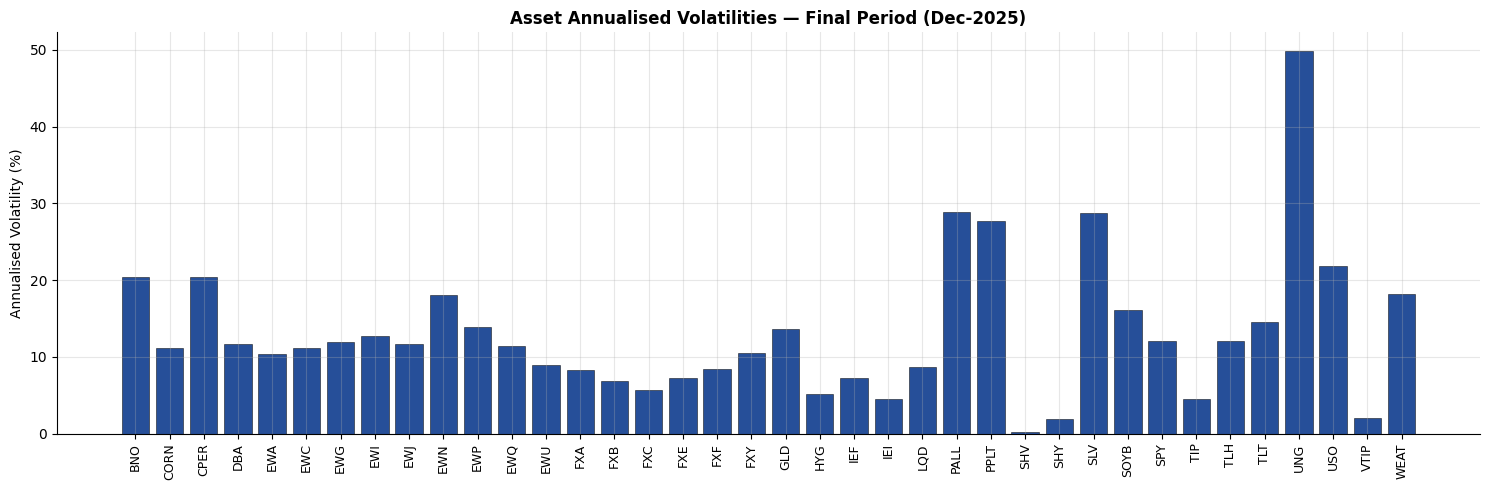

In [21]:
# Annualised volatilities — Dec-2025 bar chart
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(range(len(vols_dec)), vols_dec.values * 100, color=CU_NAVY, alpha=0.85, edgecolor="black", lw=0.4)
ax.set_xticks(range(len(vols_dec))); ax.set_xticklabels(vols_dec.index, rotation=90, fontsize=9)
ax.set_ylabel("Annualised Volatility (%)"); ax.set_title("Asset Annualised Volatilities — Final Period (Dec-2025)",
                                                          fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()


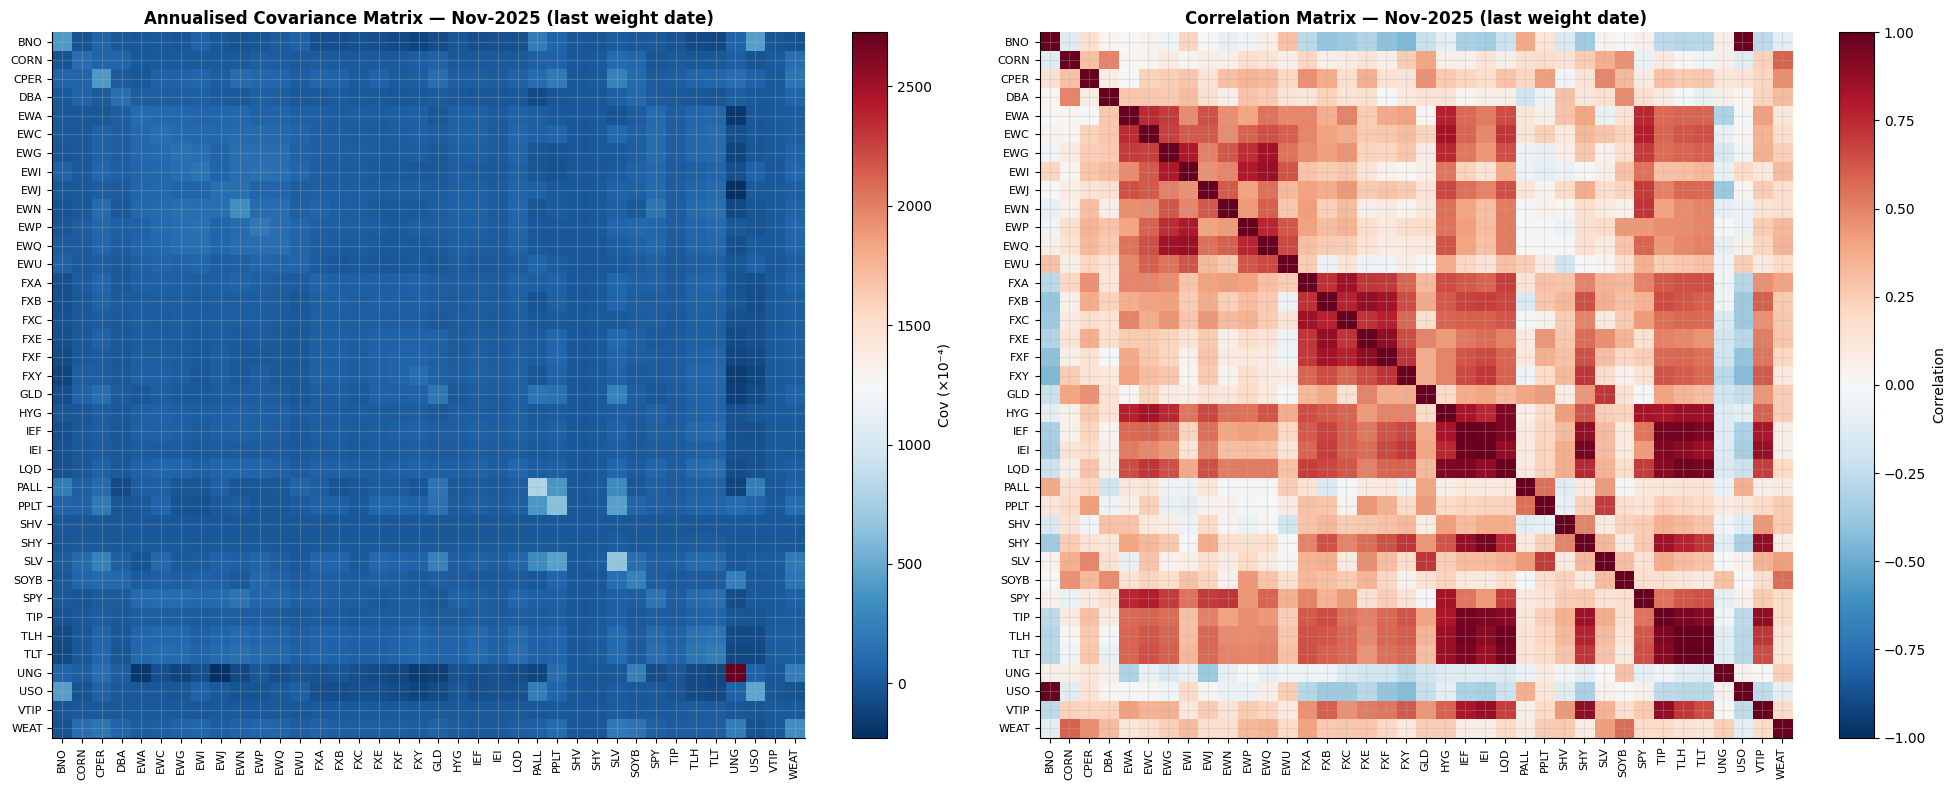

In [22]:
# Same trio for Nov-2025 (in-sample final weight date)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
im = axes[0].imshow(cov_nov.values * 1e4, cmap="RdBu_r", aspect="auto")
axes[0].set_xticks(range(len(cov_nov))); axes[0].set_yticks(range(len(cov_nov)))
axes[0].set_xticklabels(cov_nov.columns, rotation=90, fontsize=8)
axes[0].set_yticklabels(cov_nov.index, fontsize=8)
axes[0].set_title("Annualised Covariance Matrix — Nov-2025 (last weight date)", fontweight="bold")
plt.colorbar(im, ax=axes[0], label="Cov (×10⁻⁴)")

im2 = axes[1].imshow(corr_nov.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(len(corr_nov))); axes[1].set_yticks(range(len(corr_nov)))
axes[1].set_xticklabels(corr_nov.columns, rotation=90, fontsize=8)
axes[1].set_yticklabels(corr_nov.index, fontsize=8)
axes[1].set_title("Correlation Matrix — Nov-2025 (last weight date)", fontweight="bold")
plt.colorbar(im2, ax=axes[1], label="Correlation")
plt.tight_layout(); plt.show()


In [23]:
# Compact volatility table — both dates side by side
vols_table = pd.concat({"Nov-2025": vols_nov, "Dec-2025": vols_dec}, axis=1).fillna("—")
vols_table_disp = vols_table.copy()
for c in vols_table_disp.columns:
    vols_table_disp[c] = vols_table_disp[c].apply(lambda x: f"{x*100:.2f}%" if isinstance(x, float) else x)
vols_table_disp


,Nov-2025,Dec-2025
BNO,20.32%,20.38%
CORN,11.33%,11.20%
CPER,20.04%,20.45%
DBA,11.62%,11.64%
EWA,10.58%,10.33%
EWC,11.80%,11.17%
EWG,12.23%,11.93%
EWI,13.13%,12.74%
EWJ,11.73%,11.71%
EWN,18.50%,18.02%


### 14.1 Numeric Final Covariance and Correlation Matrices

The matrices below are the actual numeric objects underlying the heatmaps.
Both are 36-month annualised population estimates (`ddof=0`).

**Annualised covariance — Dec-2025 (×10⁻⁴ for readability):**


In [24]:
# Show the full numeric covariance matrix at Dec-2025 (×10⁻⁴ for readability)
cov_dec_disp = (cov_dec * 1e4).round(2)
cov_dec_disp


,BNO,CORN,CPER,DBA,EWA,EWC,EWG,EWI,EWJ,EWN,...,SLV,SOYB,SPY,TIP,TLH,TLT,UNG,USO,VTIP,WEAT
BNO,415.19,-25.27,55.22,7.39,-4.83,6.13,-14.20,53.13,1.28,-30.44,...,-2.89,7.61,10.42,-24.36,-68.39,-79.50,62.66,441.19,-10.83,-32.88
CORN,-25.27,125.52,65.49,65.32,6.61,10.28,18.78,9.51,10.71,17.23,...,99.78,79.05,-2.00,6.46,3.31,-3.92,67.77,-27.21,6.21,120.24
CPER,55.22,65.49,418.27,15.43,2.52,53.74,65.04,75.83,29.01,110.97,...,303.95,84.82,17.19,25.00,59.01,71.24,94.28,50.03,7.93,161.46
DBA,7.39,65.32,15.43,135.42,32.42,36.68,36.86,46.52,21.93,11.93,...,37.93,88.37,24.40,4.87,-2.70,-11.33,38.33,8.08,5.38,67.42
EWA,-4.83,6.61,2.52,32.42,106.80,83.80,84.03,58.04,77.02,81.91,...,-6.09,25.87,91.61,25.09,71.37,84.66,-215.11,-5.90,7.82,21.65
EWC,6.13,10.28,53.74,36.68,83.80,124.83,87.86,82.68,82.93,87.91,...,93.44,48.75,102.40,28.27,85.20,104.41,-110.39,2.62,6.75,39.78
EWG,-14.20,18.78,65.04,36.86,84.03,87.86,142.35,119.84,70.13,128.63,...,34.80,34.44,96.26,28.32,82.13,100.88,-158.85,-13.39,7.51,53.61
EWI,53.13,9.51,75.83,46.52,58.04,82.68,119.84,162.21,67.83,105.58,...,37.52,63.15,75.45,14.42,43.74,57.00,-114.19,53.94,1.32,75.65
EWJ,1.28,10.71,29.01,21.93,77.02,82.93,70.13,67.83,137.17,131.00,...,52.48,43.42,102.23,26.78,81.27,96.36,-236.63,7.15,5.86,36.24
EWN,-30.44,17.23,110.97,11.93,81.91,87.91,128.63,105.58,131.00,324.85,...,52.09,19.02,151.08,30.47,101.12,127.25,-159.73,-28.94,3.31,56.53


**Correlation — Dec-2025:**

In [25]:
# Show the full numeric correlation matrix at Dec-2025
corr_dec_disp = corr_dec.round(3)
corr_dec_disp


,BNO,CORN,CPER,DBA,EWA,EWC,EWG,EWI,EWJ,EWN,...,SLV,SOYB,SPY,TIP,TLH,TLT,UNG,USO,VTIP,WEAT
BNO,1.000,-0.111,0.133,0.031,-0.023,0.027,-0.058,0.205,0.005,-0.083,...,-0.005,0.023,0.042,-0.262,-0.277,-0.268,0.062,0.993,-0.263,-0.089
CORN,-0.111,1.000,0.286,0.501,0.057,0.082,0.140,0.067,0.082,0.085,...,0.310,0.438,-0.015,0.126,0.024,-0.024,0.121,-0.111,0.274,0.591
CPER,0.133,0.286,1.000,0.065,0.012,0.235,0.267,0.291,0.121,0.301,...,0.517,0.258,0.070,0.268,0.238,0.239,0.093,0.112,0.192,0.435
DBA,0.031,0.501,0.065,1.000,0.270,0.282,0.266,0.314,0.161,0.057,...,0.113,0.472,0.174,0.092,-0.019,-0.067,0.066,0.032,0.229,0.319
EWA,-0.023,0.057,0.012,0.270,1.000,0.726,0.682,0.441,0.636,0.440,...,-0.020,0.155,0.735,0.532,0.570,0.563,-0.418,-0.026,0.375,0.115
EWC,0.027,0.082,0.235,0.282,0.726,1.000,0.659,0.581,0.634,0.437,...,0.291,0.271,0.760,0.554,0.629,0.643,-0.198,0.011,0.299,0.196
EWG,-0.058,0.140,0.267,0.266,0.682,0.659,1.000,0.789,0.502,0.598,...,0.101,0.179,0.669,0.520,0.568,0.581,-0.267,-0.051,0.311,0.248
EWI,0.205,0.067,0.291,0.314,0.441,0.581,0.789,1.000,0.455,0.460,...,0.102,0.308,0.491,0.248,0.283,0.308,-0.180,0.194,0.051,0.327
EWJ,0.005,0.082,0.121,0.161,0.636,0.634,0.502,0.455,1.000,0.621,...,0.156,0.230,0.724,0.501,0.573,0.566,-0.406,0.028,0.248,0.170
EWN,-0.083,0.085,0.301,0.057,0.440,0.437,0.598,0.460,0.621,1.000,...,0.100,0.066,0.695,0.370,0.463,0.485,-0.178,-0.074,0.091,0.173


**Annualised covariance — Nov-2025 (×10⁻⁴):**

In [26]:
cov_nov_disp = (cov_nov * 1e4).round(2)
cov_nov_disp


,BNO,CORN,CPER,DBA,EWA,EWC,EWG,EWI,EWJ,EWN,...,SLV,SOYB,SPY,TIP,TLH,TLT,UNG,USO,VTIP,WEAT
BNO,412.77,-27.11,62.58,6.41,-1.66,9.21,-9.81,57.44,1.45,-26.53,...,18.23,-1.20,12.60,-24.49,-69.28,-80.92,64.42,438.39,-10.81,-35.94
CORN,-27.11,128.47,66.10,65.15,2.66,3.72,13.98,3.98,9.55,10.04,...,106.55,81.59,-9.74,4.74,1.21,-6.83,36.40,-27.85,5.40,120.97
CPER,62.58,66.10,401.62,17.75,0.20,54.59,61.05,72.83,29.99,110.78,...,250.40,100.99,21.37,27.27,63.36,77.66,126.53,56.84,8.82,167.24
DBA,6.41,65.15,17.75,135.10,32.86,36.73,37.55,47.09,21.82,12.15,...,45.27,86.03,24.02,4.60,-3.26,-12.15,34.64,7.14,5.28,66.59
EWA,-1.66,2.66,0.20,32.86,111.97,92.80,90.20,65.29,78.69,91.67,...,-20.12,23.88,102.51,27.64,74.62,89.19,-169.53,-4.42,9.01,21.17
EWC,9.21,3.72,54.59,36.73,92.80,139.15,98.93,95.23,85.35,103.74,...,85.58,41.06,118.88,31.77,89.26,109.96,-45.64,3.12,8.42,37.41
EWG,-9.81,13.98,61.05,37.55,90.20,98.93,149.62,128.50,72.23,140.56,...,13.98,33.11,109.90,31.60,86.41,106.87,-100.87,-11.12,9.01,53.42
EWI,57.44,3.98,72.83,47.09,65.29,95.23,128.50,172.37,70.14,119.21,...,18.73,60.13,90.61,17.95,48.21,63.23,-51.06,55.91,2.95,74.89
EWJ,1.45,9.55,29.99,21.82,78.69,85.35,72.23,70.14,137.53,133.74,...,53.78,41.30,104.86,27.27,81.75,96.99,-227.07,6.90,6.10,35.54
EWN,-26.53,10.04,110.78,12.15,91.67,103.74,140.56,119.21,133.74,342.29,...,39.79,11.63,169.54,34.48,105.88,133.80,-86.15,-27.92,5.20,54.31


**Correlation — Nov-2025:**

In [27]:
corr_nov_disp = corr_nov.round(3)
corr_nov_disp


,BNO,CORN,CPER,DBA,EWA,EWC,EWG,EWI,EWJ,EWN,...,SLV,SOYB,SPY,TIP,TLH,TLT,UNG,USO,VTIP,WEAT
BNO,1.000,-0.118,0.154,0.027,-0.008,0.038,-0.039,0.215,0.006,-0.071,...,0.035,-0.004,0.048,-0.260,-0.281,-0.274,0.061,0.992,-0.259,-0.098
CORN,-0.118,1.000,0.291,0.495,0.022,0.028,0.101,0.027,0.072,0.048,...,0.365,0.458,-0.067,0.090,0.009,-0.041,0.062,-0.113,0.231,0.590
CPER,0.154,0.291,1.000,0.076,0.001,0.231,0.249,0.277,0.128,0.299,...,0.485,0.321,0.083,0.294,0.261,0.266,0.121,0.130,0.214,0.461
DBA,0.027,0.495,0.076,1.000,0.267,0.268,0.264,0.309,0.160,0.056,...,0.151,0.471,0.161,0.085,-0.023,-0.072,0.057,0.028,0.221,0.316
EWA,-0.008,0.022,0.001,0.267,1.000,0.743,0.697,0.470,0.634,0.468,...,-0.074,0.144,0.757,0.564,0.582,0.580,-0.307,-0.019,0.413,0.111
EWC,0.038,0.028,0.231,0.268,0.743,1.000,0.686,0.615,0.617,0.475,...,0.282,0.221,0.787,0.582,0.624,0.641,-0.074,0.012,0.347,0.175
EWG,-0.039,0.101,0.249,0.264,0.697,0.686,1.000,0.800,0.504,0.621,...,0.044,0.172,0.702,0.558,0.583,0.601,-0.158,-0.042,0.358,0.241
EWI,0.215,0.027,0.277,0.309,0.470,0.615,0.800,1.000,0.456,0.491,...,0.055,0.291,0.539,0.295,0.303,0.331,-0.074,0.196,0.109,0.315
EWJ,0.006,0.072,0.128,0.160,0.634,0.617,0.504,0.456,1.000,0.616,...,0.178,0.224,0.699,0.502,0.575,0.569,-0.371,0.027,0.253,0.167
EWN,-0.071,0.048,0.299,0.056,0.468,0.475,0.621,0.491,0.616,1.000,...,0.084,0.040,0.716,0.402,0.472,0.497,-0.089,-0.069,0.137,0.162


## 15. Conclusion

This project constructs and backtests a long/short factor-based GTAA portfolio
using a disciplined two-family framework: **Cross-Asset Momentum** and
**Cross-Asset Carry**. The final expanded specification broadens the
opportunity set across equities, commodities, fixed income, and FX while
preserving the core construction logic — monthly rebalancing, 36-month
covariance estimation, 1% sleeve volatility targeting, and a strict
no-look-ahead implementation.

**Headline results:**
- Final expanded portfolio IR ≈ 0.36, max DD ≈ −2.86%.
- Carry family is the cleaner contributor (IR ≈ 0.33).
- Momentum family detracted in this sample, dragged by FI Momentum (IR ≈ −0.075)
  and FX Carry (IR ≈ −0.012).
- Cross-asset diversification keeps max DD inside any individual sleeve's worst
  drawdown (−4.2% to −5.0%).

**Audit + extended discussion**
- No-look-ahead audit:
  [`09_no_lookahead_verification.ipynb`](09_no_lookahead_verification.ipynb)
- Additional figures, extended discussion, and brief caveats:
  [`SUPPLEMENTARY_ANALYSIS.md`](../SUPPLEMENTARY_ANALYSIS.md)
